In [1]:
from src.utils import preprocess_boxes, calculate_pixel_value, horizontal_pixel_pos, horizontal_pos_conversion, predict_distance, get_image_size, resize_to_x_by_x, prepare_feature_vector
from src.model_initialization import load_yolo_model, load_posenet_model, load_depth_estimation_model, load_orientation_model, load_depth_curve_spec
from src.simulation_a_star import simulation, animate_cost_map, create_internal_obstacles
from src.direction_speed import  calculate_speed
from src.depth_estimation import estimate_depth
from src.draw_boxes import detect_persons

import numpy as np

SCALE = 0.1

In [2]:
yolo_model = load_yolo_model()
posenet_model = load_posenet_model()
orientation_model = load_orientation_model()
depth_processor, depth_model = load_depth_estimation_model()

best_fitting_depth_curve_type, best_fitting_depth_curve_param  = load_depth_curve_spec()

Using cache found in /Users/paulrichard/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-8-13 Python-3.8.18 torch-2.0.1 CPU

Fusing layers... 
YOLOv5n summary: 213 layers, 1867405 parameters, 0 gradients
Adding AutoShape... 


YOLOv5 model loaded successfully.
MoveNet (PoseNet) model loaded successfully.
Depth estimation model loaded successfully.


In [3]:
input_img = "/Users/paulrichard/Documents/HAAN/data/input/random_test/IMG_2339.jpeg"

In [4]:
DISP = True
ROBOT_SPEED = 1.11*SCALE
NEW_SIZE = (1280, 1280)
START = (int(SCALE*0),int(SCALE*0))
GOAL = (int(-20*SCALE),int(900*SCALE))
SIMULATION_TIME = 100000
DT = 100
GRID_SIZE = (1280,1000)

In [5]:
# Pre-processing of the image to our working format 
img, size_img = get_image_size(input_img)
resized_image = resize_to_x_by_x(img, NEW_SIZE)

# Person detection
coords_box_in_pixel = detect_persons(resized_image, yolo_model)

# Depth Estimation
depth_image = estimate_depth(resized_image, depth_processor, depth_model)
box_without_background = preprocess_boxes(depth_image, coords_box_in_pixel)
mean_pixel_values = calculate_pixel_value(box_without_background)
depth_values = [predict_distance(pv, best_fitting_depth_curve_param, best_fitting_depth_curve_type.lower()) for pv in mean_pixel_values]

# Horizontal position Estimation
horizontal_pos_in_pixel = horizontal_pixel_pos(coords_box_in_pixel)
horizontal_pos_in_cm = horizontal_pos_conversion(horizontal_pos_in_pixel)

# Direction and Speed Estimation
features_vector = [prepare_feature_vector(resized_image, box, posenet_model, depth) for box, depth in zip(coords_box_in_pixel, depth_values)]
directions = [orientation_model.predict(features) for features in features_vector]
directions_in_radians = [np.radians(direction[0]) for direction in directions]
#directions_in_radians[0]= np.pi*3/2 
speeds = calculate_speed(resized_image, coords_box_in_pixel)

# Creating the obstacles for Simulation
num_obstacles = len(coords_box_in_pixel) 
dynamic_obstacles_pos = np.zeros((num_obstacles, 2)) 
dynamic_obstalcles_dir_speed = []  
for i, (horizontal_pos, depth, direction, speed) in enumerate(zip(horizontal_pos_in_cm, depth_values, directions_in_radians, speeds)):
    x_position = int(horizontal_pos*SCALE)
    y_position = int(depth*SCALE)
    
    dynamic_obstacles_pos[i, :] = [x_position, y_position]
    dynamic_obstalcles_dir_speed.append((direction, speed))

Person detection complete. Found 3 persons.


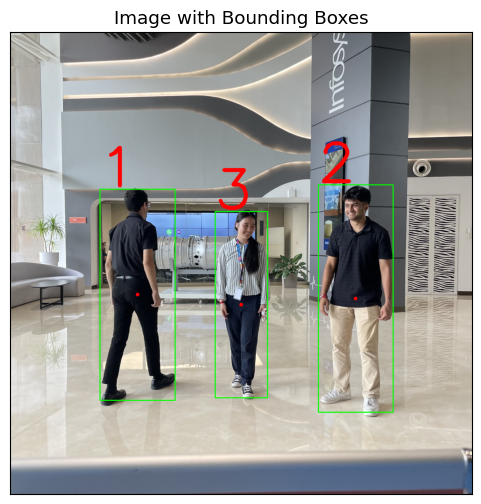

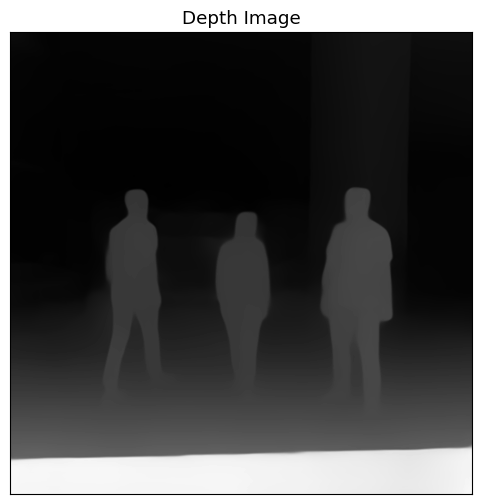

MoveNet (PoseNet) model loaded successfully.


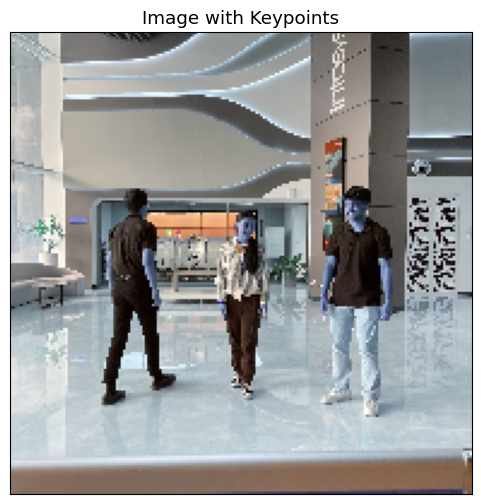

2024-08-22 16:48:00,103 - root - ERROR - An error occurred in display_original_and_depth: Can't convert object of type 'numpy.ndarray' to 'str' for 'filename'


In [6]:
%matplotlib inline

from src.utils import draw_boxes, draw_keypoints, display_img, display_original_and_depth, extract_and_scale_keypoints, calculate_average_angle

# 1. Affichage de l'image originale avec la boîte englobante
boxed_image = draw_boxes(resized_image, coords_box_in_pixel)
if boxed_image is not None:
    display_img(boxed_image, title="Image with Bounding Boxes")

# 2. Affichage de l'image de profondeur seule
if depth_image is not None:
    display_img(depth_image, title="Depth Image")

# 3. Affichage de l'image avec les keypoints
image, _ = get_image_size(input_img)
resized_image = resize_to_x_by_x(image, (192, 192))  # Redimensionner l'image pour la taille d'entrée de PoseNet
posenet_model = load_posenet_model()  # Charger le modèle PoseNet (cette fonction doit être définie ailleurs)
keypoints_scaled = extract_and_scale_keypoints(resized_image, posenet_model)
if resized_image is not None:
    display_img(resized_image, title="Image with Keypoints")

# 4. Affichage de l'image avec les keypoints, la boîte englobante et la direction
depth_image_np = np.array(depth_image)  # Convertir l'image de profondeur en tableau numpy
if depth_image_np is not None:
    display_original_and_depth(resized_image, depth_image_np, coords_box_in_pixel)

In [7]:
dynamic_obstalcles_dir_speed[0]= (np.pi/4, 1)
dynamic_obstalcles_dir_speed[1]= (3*np.pi/2, 1)
dynamic_obstalcles_dir_speed[2]= (3*np.pi/2, 1)


#num_obstacles = 20
#dynamic_obstacles_pos, dynamic_obstalcles_dir_speed = create_internal_obstacles(num_obstacles)

In [8]:
#Simulation:
robot_positions, cost_map_times, dynamic_obstacles_times, path_times, dynamic_obstalcles_dir_speed_times= simulation(   dynamic_obstacles_pos, 
                                                                                                                        dynamic_obstalcles_dir_speed, 
                                                                                                                        START, 
                                                                                                                        GOAL, 
                                                                                                                        ROBOT_SPEED, 
                                                                                                                        SIMULATION_TIME, 
                                                                                                                        DT
                                                                                                                    )

Simulation Progress:   0%|          | 2/1000 [00:00<01:55,  8.66it/s]

Goal reached in 1032 iterations !
Goal reached in 999 iterations !


Simulation Progress:   0%|          | 4/1000 [00:00<01:53,  8.78it/s]

Goal reached in 971 iterations !
Goal reached in 942 iterations !


Simulation Progress:   1%|          | 6/1000 [00:00<01:52,  8.83it/s]

...

Goal reached in 240 iterations !
Goal reached in 232 iterations !
Goal reached in 222 iterations !
Goal reached in 213 iterations !
Goal reached in 229 iterations !
Goal reached in 219 iterations !
Goal reached in 209 iterations !
Goal reached in 199 iterations !


Simulation Progress:   7%|▋         | 69/1000 [00:04<00:32, 28.85it/s]

Goal reached in 189 iterations !
Goal reached in 180 iterations !
Goal reached in 171 iterations !
Goal reached in 162 iterations !
Goal reached in 153 iterations !
Goal reached in 144 iterations !
Goal reached in 135 iterations !


Simulation Progress:   9%|▉         | 91/1000 [00:05<00:51, 17.75it/s]

Goal reached in 125 iterations !
Goal reached in 117 iterations !
Goal reached in 109 iterations !
Goal reached in 100 iterations !
Goal reached in 91 iterations !
Goal reached in 81 iterations !
Goal reached in 72 iterations !
Goal reached in 64 iterations !
Goal reached in 57 iterations !
Goal reached in 49 iterations !
Goal reached in 41 iterations !
Goal reached in 33 iterations !
Goal reached in 26 iterations !
Goal reached in 21 iterations !
Goal reached in 15 iterations !
Goal reached in 11 iterations !
Goal reached in 9 iterations !
Goal reached in 6 iterations !
Goal reached in 4 iterations !
Goal reached in 2 iterations !
Goal reached in 1 iterations !


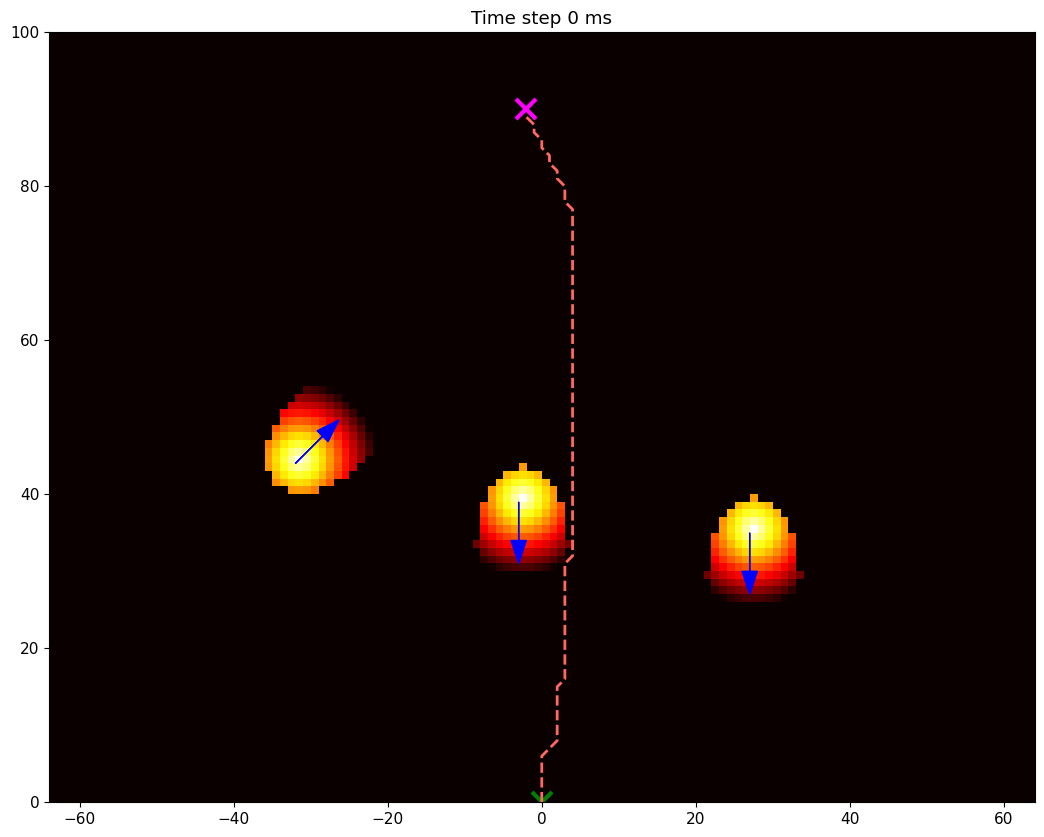

In [9]:
# Animate the simulation results
anim = animate_cost_map(cost_map_times, robot_positions, dynamic_obstacles_times, dynamic_obstalcles_dir_speed_times, GOAL, SIMULATION_TIME, DT, path_times)

# Display the animation
from IPython.display import HTML
HTML(anim.to_jshtml())

In [10]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, writers

# Set up the writer for saving as MP4
Writer = writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)

# Save the animation as an MP4 file
anim.save('/Users/paulrichard/Documents/HAAN/animation5.mp4', writer=writer)